# Phase 3 — Step 2: The Ingestion Agent & Router-Index

## Objective

Phase 2 retrieved at the *chunk* level: for every query we searched all 228 chunks with ChromaDB + BM25. That is acceptable at 228 chunks but will not scale to thousands of documents. The classical solution is a **two-stage retrieval**: first a *router* picks the right document (or small set of documents), then the chunk-level ensemble retriever runs only inside those documents.

The router needs one vector *per document*. The question this notebook answers is: **what do we put in that vector?**

## Two competing strategies

- **Router A (Baseline)** — embed the **raw full text** of the document. Simple, no LLM involved at ingestion time, but a ~2 kB document with headers, boilerplate, formatting artefacts, and repeated disclaimers produces a vector whose signal is diluted by noise.
- **Router B (Cognitive)** — ask Llama 3.2 to produce a **Key Semantic Points** (KSP) summary: 60–120 words capturing the document's *topics*, *roles*, and *purpose*, with boilerplate stripped. Embed only the KSP.

The hypothesis: dense KSPs spread documents further apart in embedding space, so the router's top-1 pick is less ambiguous and retrieval is more confident.

## Security inheritance

Each KSP inherits the document's ground-truth `clearance_level` and `allowed_departments` (from the metadata assigned in Phase 3 Step 1). The router entry is therefore a first-class RBAC object: the Asymmetric Fusion pre-filter from Phase 2 Step 4 can sit on top of this router without modification.

## Metrics

For 10 tricky queries:
- **Top-1 accuracy** — does the router return the correct document first?
- **Mean Reciprocal Rank** — averaged rank of the correct document.
- **Routing margin** — `dist(top2) − dist(top1)`. A larger margin means the router was more confident about its choice. This is the "noise elimination" metric.

Plus a **global map-clarity** metric: the distribution of pairwise inter-document distances. A cleaner map (Router B) should show distances that are higher on average and have no accidentally-close pairs.

In [1]:
# Cell 1 — Imports, paths, Ollama, embedding model, ChromaDB
import json, os, re, time, statistics
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import requests
import chromadb
from langchain_huggingface import HuggingFaceEmbeddings
import matplotlib.pyplot as plt

BASE          = os.path.dirname(os.path.abspath("__file__"))
RAW_DOCS_DIR  = os.path.join(BASE, "..", "..", "data", "raw_docs")
PH1_LOADED    = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph1", "loaded_documents.json")
PH2_CHUNKS    = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph2", "ph2_plus_augmented_chunks.json")
RESULTS_DIR   = os.path.join(BASE, "..", "..", "data", "results", "notebook_results", "ph3")
os.makedirs(RESULTS_DIR, exist_ok=True)

OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL      = "llama3.2"

# Ollama ready?
r = requests.get("http://localhost:11434/api/tags", timeout=5)
assert any(MODEL in m["name"] for m in r.json()["models"])
print(f"Ollama ready. Model: {MODEL}")

# Embedding model — same one used in Phase 2 for consistency
print("Loading embedding model all-MiniLM-L6-v2 ...")
embed = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={"device": "cpu"})
print("Embedding model ready.")

# In-memory ChromaDB client
chroma = chromadb.Client()
print("ChromaDB in-memory client ready.")

Ollama ready. Model: llama3.2
Loading embedding model all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model ready.


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


ChromaDB in-memory client ready.


## Cell 2 — Load the 23 documents with their ground-truth metadata

Same source as Phase 3 Step 1: raw `.txt` / `.md` files from `raw_docs/` and pre-extracted text from `loaded_documents.json` for the PDF / DOCX / XLSX originals. Document-level `clearance_level`, `allowed_departments`, and `global_topic` are compiled from the Phase 2 augmented chunks metadata.

In [2]:
# Cell 2 — Build the document set (23 docs)

@dataclass
class Doc:
    source: str
    text: str
    clearance_level: int
    allowed_departments: str
    doc_type: str
    global_topic: str

with open(PH2_CHUNKS, "r", encoding="utf-8") as f:
    corpus = json.load(f)
with open(PH1_LOADED, "r", encoding="utf-8") as f:
    loaded = json.load(f)

def read_doc_text(source: str) -> str:
    path = os.path.join(RAW_DOCS_DIR, source)
    if os.path.exists(path) and source.lower().endswith((".txt", ".md")):
        with open(path, "r", encoding="utf-8") as fp:
            return fp.read()
    if source in loaded:
        return "\n".join(p["page_content"] for p in loaded[source])
    raise FileNotFoundError(source)

DOCS: list[Doc] = []
for src, chunks in corpus.items():
    m0 = chunks[0]["metadata"]
    DOCS.append(Doc(
        source=src,
        text=read_doc_text(src),
        clearance_level=min(int(c["metadata"].get("clearance_level", 0)) for c in chunks),
        allowed_departments=str(m0.get("allowed_departments", "all")).lower(),
        doc_type=str(m0.get("doc_type", "unknown")).lower(),
        global_topic=str(m0.get("global_topic", m0.get("doc_topic", ""))),
    ))

print(f"Loaded {len(DOCS)} documents.")
print(f"  mean doc length : {sum(len(d.text) for d in DOCS) / len(DOCS):.0f} chars")
print(f"  max doc length  : {max(len(d.text) for d in DOCS)} chars")
print(f"  total chars     : {sum(len(d.text) for d in DOCS):,}")

Loaded 23 documents.
  mean doc length : 1194 chars
  max doc length  : 2458 chars
  total chars     : 27,471


## Cell 3 — Generate Key Semantic Points (the Ingestion Agent)

For every document, Llama 3.2 produces a dense 60–120 word fingerprint. The prompt enforces three constraints to keep the KSPs as informative as possible for routing:

1. **Name topics and roles, not names.** Saying "the CFO" instead of "Chiara Colombo" keeps PII out of the router while preserving the semantic signal.
2. **Strip boilerplate.** No "this document covers", no salutations, no generic openers.
3. **Use active purpose verbs.** "*reports* Q1 revenue and margins", "*defines* rules for employee expenses", "*logs* server activity". These verbs separate doc_types in embedding space.

In [3]:
# Cell 3 — KSP generator

KSP_PROMPT = """You are the Ingestion Agent for an enterprise RAG system. Given a document, produce a DENSE Key Semantic Points (KSP) summary that will be EMBEDDED and used as a vector fingerprint for document routing.

HARD RULES for the KSP:
- Length: 60 to 120 words, single paragraph or short bullet list.
- NAME TOPICS and ROLES ("the CFO", "the Spanish distributor"), NEVER personal names, DNIs, IBANs, or any raw PII value.
- STRIP BOILERPLATE: no salutations, no generic openers ("this document covers…"), no formatting artefacts.
- USE ACTIVE PURPOSE VERBS: "reports", "defines", "specifies", "logs", "describes", "contracts", "authorises".
- Include: the doc's genre (report / contract / log / policy / manual / memo / directory / minutes / guide), the key SUBJECT (revenue, VPN config, onboarding, photocell alignment, ...), the SCOPE (time period, department, product line, client name if it IS the doc's purpose).
- EXCLUDE: any value whose leak would be sensitive (passwords, token strings, IBAN numbers, salary amounts — you can say "contains a salary band" but not the figures).

OUTPUT: a single JSON object, no prose, no markdown:
{
  "key_semantic_points": "<the dense KSP text, 60-120 words>",
  "reasoning": "<one short sentence>"
}

FEW-SHOT

Doc: "MICROGATE S.R.L. - QUARTERLY FINANCIAL REPORT (Q3 2025). Department: Finance. CONFIDENTIAL. 1. Executive Summary: Witty Timer product line reached €4.2M revenue this quarter, up 18% YoY. 2. Margins stable at 62% gross. R&D spend of €1.5M allocated for 2026."
Response: {"key_semantic_points":"Quarterly financial report for the Witty Timer product line covering Q3 2025. Reports revenue figures, year-over-year growth, gross margin, and R&D budget allocation for the following year. Audience is the finance department at strict clearance. Contains specific monetary figures and strategic commentary. Genre: finance report. Scope: one fiscal quarter for one product line.","reasoning":"Quarterly finance report, product line scope."}

Doc: "VPN Configuration Guide. Download WireGuard. Gateway at vpn.microgate.it. UDP port 51820. Subnets 10.0.1.0/24 production, 10.0.2.0/24 dev."
Response: {"key_semantic_points":"Engineering configuration guide describing how to set up the corporate WireGuard VPN. Specifies the gateway hostname, the UDP port, the production and development subnets, and troubleshooting steps for failed connections. Audience is the engineering department at internal clearance. Contains no secret values, only topology and client-side steps. Genre: technical guide. Scope: one remote-access system.","reasoning":"VPN setup guide, engineering scope."}
"""

def generate_ksp(text: str, retries: int = 1) -> dict:
    prompt = f"{KSP_PROMPT}\n\nNow generate the KSP for this document:\n---\n{text}\n---\nResponse:"
    t0 = time.perf_counter()
    for attempt in range(retries + 1):
        try:
            resp = requests.post(OLLAMA_URL, json={
                "model": MODEL, "prompt": prompt, "stream": False, "format": "json",
                "options": {"temperature": 0.1, "num_predict": 380, "num_ctx": 8192},
            }, timeout=180)
            raw = resp.json().get("response", "").strip()
            raw = re.sub(r"^```(?:json)?|```$", "", raw, flags=re.IGNORECASE).strip()
            parsed = json.loads(raw)
            ksp = str(parsed.get("key_semantic_points", "")).strip()
            if len(ksp) < 40:
                raise ValueError("KSP too short")
            return {
                "ksp": ksp,
                "reasoning": str(parsed.get("reasoning", ""))[:240],
                "latency_s": round(time.perf_counter() - t0, 2),
                "parse_retries": attempt,
            }
        except (json.JSONDecodeError, ValueError, KeyError, TypeError):
            continue
    # Fallback — use first 300 chars of doc as a degraded KSP
    return {"ksp": text[:300], "reasoning": "parse_failure_fallback",
            "latency_s": round(time.perf_counter() - t0, 2), "parse_retries": retries + 1}

# Run on all 23 documents
print(f"Generating Key Semantic Points for {len(DOCS)} documents...\n")
ksps: list[dict] = []
t_start = time.time()
for i, d in enumerate(DOCS, 1):
    out = generate_ksp(d.text)
    ksps.append({"source": d.source, "ksp": out["ksp"], "reasoning": out["reasoning"],
                 "latency_s": out["latency_s"], "doc_chars": len(d.text), "ksp_chars": len(out["ksp"])})
    print(f"  [{i:02d}/{len(DOCS)}] {d.source:<40} doc={len(d.text):>5}ch ksp={len(out['ksp']):>4}ch  ({out['latency_s']:.1f}s)")
print(f"\nTotal: {time.time() - t_start:.0f}s  |  mean KSP length: {sum(k['ksp_chars'] for k in ksps) / len(ksps):.0f} chars")

# Show 3 KSPs as sanity check
print("\n" + "=" * 78)
print("  Sample KSPs")
print("=" * 78)
for k in [ksps[0], ksps[7], ksps[15]]:
    print(f"\n  [{k['source']}]")
    print(f"  {k['ksp']}")

Generating Key Semantic Points for 23 documents...



  [01/23] Witty-QuickGuide-EN.pdf                  doc= 2249ch ksp= 266ch  (10.8s)


  [02/23] Witty-Financial-Report-2025.pdf          doc= 2458ch ksp= 377ch  (8.3s)


  [03/23] distribution-contract-2026.docx          doc= 1059ch ksp= 279ch  (6.6s)


  [04/23] server_logs_witty_backend.txt            doc=  653ch ksp= 266ch  (6.6s)


...

  [19/23] product_photocell_alignment.md           doc= 1548ch ksp= 355ch  (7.6s)


  [20/23] product_release_notes_v4.txt             doc=  964ch ksp= 404ch  (7.8s)


  [21/23] memo_q2_sales_targets.txt                doc= 1059ch ksp= 256ch  (6.7s)


  [22/23] memo_it_security_reminder.txt            doc= 1423ch ksp= 325ch  (6.6s)


  [23/23] memo_board_meeting_minutes.txt           doc= 1285ch ksp= 334ch  (7.2s)

Total: 165s  |  mean KSP length: 310 chars

  Sample KSPs

  [Witty-QuickGuide-EN.pdf]
  Quick guide for setting up the Witty Manager software and photocell alignment. Specifies user manual contents, installation steps, and usage instructions. Includes hardware components and troubleshooting tips. Genre: technical guide. Scope: one remote-access system.

  [fin_expense_policy.md]
  Corporate expense policy for Microgate S.R.L., covering travel expenses, equipment purchases, reimbursement process, corporate credit cards, and audit trail. Reports financial guidelines, approval processes, and compliance requirements for the finance department. Genre: corporate policy. Scope: one company-wide directive, effective January 2026.

  [contract_universidad_deporte.txt]
  Academic collaboration agreement between Microgate S.R.L. and Universidad del Deporte for research in biomechanics using Witty Timer as a measur

## Cell 4 — Build the two Router-Indexes

**Router A** embeds each document's raw text. Note: `all-MiniLM-L6-v2` has a 256-token context window (~1 kB) — longer documents are silently truncated by the tokenizer, which *is* part of the baseline's handicap and what we want to expose.

**Router B** embeds the KSP, which is always within context by design.

Both routers carry the document's `clearance_level`, `allowed_departments`, and `doc_type` as metadata, so Zero-Trust filtering (Phase 2 Asymmetric Fusion) can sit on top of either router without modification.

In [4]:
# Cell 4 — Build Router A (full text) and Router B (KSPs)

ksp_by_src = {k["source"]: k["ksp"] for k in ksps}

router_a_docs   = [d.text      for d in DOCS]
router_b_docs   = [ksp_by_src[d.source] for d in DOCS]
metas = [{
    "source": d.source,
    "clearance_level":    d.clearance_level,
    "allowed_departments": d.allowed_departments,
    "doc_type":           d.doc_type,
} for d in DOCS]
ids = [f"doc_{i:02d}" for i in range(len(DOCS))]

# Compute embeddings
print("Embedding Router A (raw text)...")
t0 = time.time()
emb_a = embed.embed_documents(router_a_docs)
print(f"  A: {len(emb_a)} vectors in {time.time() - t0:.1f}s")

print("Embedding Router B (KSPs)...")
t0 = time.time()
emb_b = embed.embed_documents(router_b_docs)
print(f"  B: {len(emb_b)} vectors in {time.time() - t0:.1f}s")

# ChromaDB collections
for name in ["router_a_fulltext", "router_b_ksp"]:
    try: chroma.delete_collection(name)
    except Exception: pass

coll_a = chroma.create_collection(name="router_a_fulltext", metadata={"hnsw:space": "cosine"})
coll_b = chroma.create_collection(name="router_b_ksp",       metadata={"hnsw:space": "cosine"})

coll_a.add(documents=router_a_docs, embeddings=emb_a, ids=ids, metadatas=metas)
coll_b.add(documents=router_b_docs, embeddings=emb_b, ids=ids, metadatas=metas)

print(f"\nRouter A populated: {coll_a.count()} documents indexed.")
print(f"Router B populated: {coll_b.count()} documents indexed.")

Embedding Router A (raw text)...


  A: 23 vectors in 2.3s
Embedding Router B (KSPs)...
  B: 23 vectors in 0.2s


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given



Router A populated: 23 documents indexed.
Router B populated: 23 documents indexed.


## Cell 5 — Tricky query suite (10 queries with ground-truth routing target)

Each query targets **one specific document**, chosen so that several other documents share surface-level vocabulary — the exact situation where a full-text baseline is prone to routing to a neighbour. Ground truth is the file that a human answering the query would naturally cite.

In [5]:
# Cell 5 — Tricky queries

@dataclass
class Query:
    qid: str
    question: str
    target: str   # expected top-1 document
    reason: str   # why this is tricky

QUERIES: list[Query] = [
    Query("Q01",
          "Which IBAN is used to collect payments from the exclusive Spanish distributor?",
          "distribution-contract-2026.docx",
          "Multiple docs mention IBANs; only this one covers the exclusive distribution deal."),
    Query("Q02",
          "How do I align the photocells on the training timer and verify the beam?",
          "product_photocell_alignment.md",
          "Product specs also mention photocells; only this doc covers the alignment procedure."),
    Query("Q03",
          "What is the monthly spending limit on a corporate credit card?",
          "fin_expense_policy.md",
          "Other finance docs mention spending; only the policy has the monthly card limit."),
    Query("Q04",
          "Which employee holds the Lead Developer position in engineering?",
          "hr_employee_directory.txt",
          "Board minutes also reference engineering roles; the directory is the authoritative source."),
    Query("Q05",
          "What root cause was identified for the brute-force attack on the API login endpoint?",
          "it_incident_report_IR2026_003.txt",
          "Server logs and the security memo also mention brute-force; only the incident report has the root cause."),
    Query("Q06",
          "Which board members authorised the 2027 R&D budget increase?",
          "memo_board_meeting_minutes.txt",
          "Budget forecast doc and sales memo also mention R&D; only the minutes record the authorisation."),
    Query("Q07",
          "What is the annual service fee for the FitPlus gyms maintenance SLA?",
          "contract_fitplus_maintenance.txt",
          "Several contracts have pricing; the FitPlus SLA is unique."),
    Query("Q08",
          "Which UDP port must the firewall allow for the corporate VPN client to connect?",
          "it_vpn_config_guide.md",
          "Security memo also talks about remote access; only the VPN guide has the port number."),
    Query("Q09",
          "How many hours of continuous use does the Witty Timer unit battery support?",
          "product_witty_timer_specs.md",
          "Release notes and photocell guide also mention batteries; only the specs doc has the hour figure."),
    Query("Q10",
          "Summarise Q1 2026 revenue broken down by geographic region.",
          "fin_q1_2026_revenue.txt",
          "Budget forecast and board minutes also reference revenue; only this one reports Q1-by-region."),
]

print(f"Tricky query set built: {len(QUERIES)} queries covering {len(set(q.target for q in QUERIES))} distinct target documents.")

Tricky query set built: 10 queries covering 10 distinct target documents.


## Cell 6 — Execute queries against both routers + routing metrics

For each query we ask each router for the top-5 ranked documents plus their cosine distances. We compute, per query:

- `rank_of_target` — where the correct doc landed (1 = perfect routing).
- `margin` — cosine-distance gap between the top-1 and top-2 results. A large positive margin means the router was confident about its pick. A small margin means the top-2 candidates were nearly indistinguishable.

In [6]:
# Cell 6 — Run both routers

def route(collection, query_text: str, k: int = 5) -> list[dict]:
    qe = embed.embed_query(query_text)
    r = collection.query(query_embeddings=[qe], n_results=k,
                         include=["metadatas", "distances"])
    return [{"source": m["source"], "distance": d}
            for m, d in zip(r["metadatas"][0], r["distances"][0])]

def rank_of(results: list[dict], target: str) -> int:
    for i, r in enumerate(results, 1):
        if r["source"] == target:
            return i
    return 99  # not in top-k

rows = []
print(f"{'Query':<5} {'target':<35} {'A top-1':<35} {'A r':>3} {'A margin':>8}  |  {'B top-1':<35} {'B r':>3} {'B margin':>8}")
print("-" * 160)
for q in QUERIES:
    ra = route(coll_a, q.question, k=5)
    rb = route(coll_b, q.question, k=5)
    rk_a = rank_of(ra, q.target)
    rk_b = rank_of(rb, q.target)
    margin_a = round(ra[1]["distance"] - ra[0]["distance"], 4)
    margin_b = round(rb[1]["distance"] - rb[0]["distance"], 4)
    rows.append({
        "qid": q.qid, "question": q.question, "target": q.target,
        "A_top1": ra[0]["source"], "A_rank": rk_a, "A_margin": margin_a, "A_top5": [(r["source"], round(r["distance"],4)) for r in ra],
        "B_top1": rb[0]["source"], "B_rank": rk_b, "B_margin": margin_b, "B_top5": [(r["source"], round(r["distance"],4)) for r in rb],
    })
    print(f"{q.qid:<5} {q.target[:35]:<35} {ra[0]['source'][:35]:<35} {rk_a:>3} {margin_a:>8.4f}  |  "
          f"{rb[0]['source'][:35]:<35} {rk_b:>3} {margin_b:>8.4f}")

res = pd.DataFrame(rows)

def top1(df, col): return (df[col] == 1).sum() / len(df) * 100
def topk(df, col, k): return (df[col] <= k).sum() / len(df) * 100
def mrr(df, col):     return (1 / df[col]).mean()

print("\n" + "=" * 70)
print("  ROUTING METRICS")
print("=" * 70)
print(f"{'Metric':<28}{'Router A':>12}{'Router B':>12}")
print("-" * 52)
print(f"{'Top-1 accuracy':<28}{top1(res,'A_rank'):>11.1f}%{top1(res,'B_rank'):>11.1f}%")
print(f"{'Top-3 accuracy':<28}{topk(res,'A_rank',3):>11.1f}%{topk(res,'B_rank',3):>11.1f}%")
print(f"{'Mean Reciprocal Rank':<28}{mrr(res,'A_rank'):>12.3f}{mrr(res,'B_rank'):>12.3f}")
print(f"{'Mean routing margin':<28}{res['A_margin'].mean():>12.4f}{res['B_margin'].mean():>12.4f}")
print(f"{'Median routing margin':<28}{res['A_margin'].median():>12.4f}{res['B_margin'].median():>12.4f}")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Query target                              A top-1                             A r A margin  |  B top-1                             B r B margin
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Q01   distribution-contract-2026.docx     memo_q2_sales_targets.txt            99   0.0588  |  distribution-contract-2026.docx       1   0.1665
Q02   product_photocell_alignment.md      product_photocell_alignment.md        1   0.4325  |  product_photocell_alignment.md        1   0.1433
Q03   fin_expense_policy.md               fin_expense_policy.md                 1   0.1560  |  fin_expense_policy.md                 1   0.0719
Q04   hr_employee_directory.txt           hr_salary_bands_2026.txt              2   0.0839  |  hr_employee_directory.txt             1   0.0762
Q05   it_incident_report_IR2026_003.txt   it_incident_report_IR2026_003.txt     1   0.1391  |  it_incident_report_IR202

Q07   contract_fitplus_maintenance.txt    contract_fitplus_maintenance.txt      1   0.2586  |  contract_fitplus_maintenance.txt      1   0.2392
Q08   it_vpn_config_guide.md              it_vpn_config_guide.md                1   0.2975  |  it_vpn_config_guide.md                1   0.3640


Q09   product_witty_timer_specs.md        product_witty_timer_specs.md          1   0.1857  |  product_witty_timer_specs.md          1   0.0504
Q10   fin_q1_2026_revenue.txt             fin_q1_2026_revenue.txt               1   0.0781  |  fin_q1_2026_revenue.txt               1   0.0177

  ROUTING METRICS
Metric                          Router A    Router B
----------------------------------------------------
Top-1 accuracy                     70.0%       90.0%
Top-3 accuracy                     90.0%      100.0%
Mean Reciprocal Rank               0.801       0.933
Mean routing margin               0.1743      0.1393
Median routing margin             0.1476      0.1316


## Cell 7 — Global map-clarity: inter-document distance distribution

Independent of any query, we compare how the two routers *spread out* the 23 documents in embedding space. For each router we compute all 253 pairwise cosine distances. A cleaner map has:

- A **higher mean** — documents are further apart on average.
- A **higher minimum** — no two docs accidentally end up nearly identical.
- A **tighter standard deviation** centred higher — consistency of separation.

If Router B shows a cleaner map globally, then the gain observed per-query in Cell 6 generalises beyond those 10 examples.

In [7]:
# Cell 7 — Pairwise inter-document distances

def pairwise_cosine_distances(vectors: list[list[float]]) -> np.ndarray:
    A = np.asarray(vectors)
    A = A / np.linalg.norm(A, axis=1, keepdims=True)
    sims = A @ A.T
    dists = 1.0 - sims
    n = dists.shape[0]
    return dists[np.triu_indices(n, k=1)]

d_a = pairwise_cosine_distances(emb_a)
d_b = pairwise_cosine_distances(emb_b)

def stats_block(d: np.ndarray) -> dict:
    return {
        "n_pairs": int(d.size),
        "mean":  round(float(d.mean()),  4),
        "median": round(float(np.median(d)), 4),
        "min":   round(float(d.min()),   4),
        "max":   round(float(d.max()),   4),
        "std":   round(float(d.std()),   4),
    }

stats_a = stats_block(d_a)
stats_b = stats_block(d_b)
print("=" * 60)
print("  PAIRWISE INTER-DOCUMENT COSINE DISTANCES")
print("=" * 60)
print(f"  {'Stat':<10}{'Router A':>15}{'Router B':>15}{'Δ (B-A)':>12}")
for k in ["n_pairs", "mean", "median", "min", "max", "std"]:
    delta = stats_b[k] - stats_a[k] if k != "n_pairs" else 0
    print(f"  {k:<10}{stats_a[k]:>15}{stats_b[k]:>15}{delta:>+12.4f}")

# Identify the closest (most-confusing) pair for each router
def closest_pair(d_flat: np.ndarray, n: int) -> tuple[int, int, float]:
    idx = np.argmin(d_flat)
    iu = np.triu_indices(n, k=1)
    return int(iu[0][idx]), int(iu[1][idx]), float(d_flat[idx])

i_a, j_a, v_a = closest_pair(d_a, len(DOCS))
i_b, j_b, v_b = closest_pair(d_b, len(DOCS))
print(f"\n  Closest (most-confusing) pair in Router A:  distance={v_a:.4f}")
print(f"    {DOCS[i_a].source}  <>  {DOCS[j_a].source}")
print(f"  Closest (most-confusing) pair in Router B:  distance={v_b:.4f}")
print(f"    {DOCS[i_b].source}  <>  {DOCS[j_b].source}")

  PAIRWISE INTER-DOCUMENT COSINE DISTANCES
  Stat             Router A       Router B     Δ (B-A)
  n_pairs               253            253     +0.0000
  mean               0.6998         0.7573     +0.0575
  median             0.7216         0.7885     +0.0669
  min                0.2573         0.0737     -0.1836
  max                1.0255         1.0051     -0.0204
  std                0.1543         0.1472     -0.0071

  Closest (most-confusing) pair in Router A:  distance=0.2573
    distribution-contract-2026.docx  <>  contract_federacion_atletismo.txt
  Closest (most-confusing) pair in Router B:  distance=0.0737
    Witty-Financial-Report-2025.pdf  <>  fin_q1_2026_revenue.txt


## Cell 8 — Visualisation

Two charts:
1. Per-query routing margin (bar chart, A vs B side-by-side) — shows which queries gained the most from KSPs.
2. Histogram of inter-document distances — shows the global noise reduction.

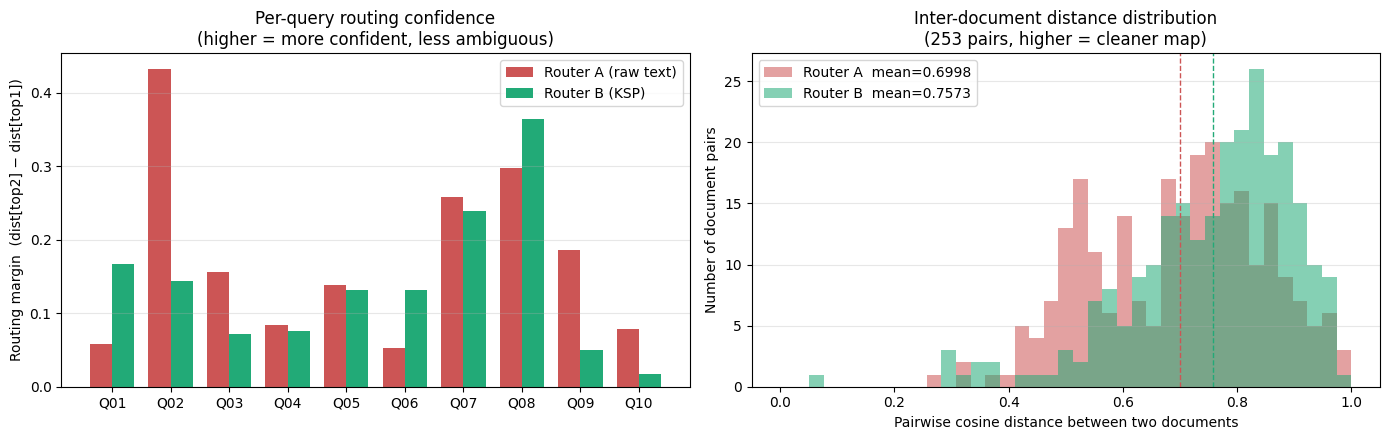

Saved: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step2_router_comparison.png


In [8]:
# Cell 8 — Visualisations

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Per-query margin comparison
x = np.arange(len(res))
w = 0.38
axes[0].bar(x - w/2, res["A_margin"], width=w, label="Router A (raw text)",  color="#C55")
axes[0].bar(x + w/2, res["B_margin"], width=w, label="Router B (KSP)",       color="#2A7")
axes[0].set_xticks(x)
axes[0].set_xticklabels(res["qid"], rotation=0)
axes[0].set_ylabel("Routing margin  (dist[top2] − dist[top1])")
axes[0].set_title("Per-query routing confidence\n(higher = more confident, less ambiguous)")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# (2) Inter-doc distance histograms
bins = np.linspace(0, 1.0, 40)
axes[1].hist(d_a, bins=bins, alpha=0.55, label=f"Router A  mean={stats_a['mean']}",  color="#C55")
axes[1].hist(d_b, bins=bins, alpha=0.55, label=f"Router B  mean={stats_b['mean']}",  color="#2A7")
axes[1].axvline(stats_a["mean"], color="#C55", linestyle="--", lw=1)
axes[1].axvline(stats_b["mean"], color="#2A7", linestyle="--", lw=1)
axes[1].set_xlabel("Pairwise cosine distance between two documents")
axes[1].set_ylabel("Number of document pairs")
axes[1].set_title(f"Inter-document distance distribution\n({stats_a['n_pairs']} pairs, higher = cleaner map)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "ph3_step2_router_comparison.png")
plt.savefig(plot_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Cell 9 — Export + summary

In [9]:
# Cell 9 — Persist results and print the headline numbers

out = {
    "step": "Phase 3 - Step 2: Ingestion Agent & Router-Index",
    "model": MODEL,
    "n_documents": len(DOCS),
    "n_queries":   len(QUERIES),
    "ksp_generation": {
        "mean_latency_s":  round(sum(k["latency_s"] for k in ksps) / len(ksps), 2),
        "total_latency_s": round(sum(k["latency_s"] for k in ksps), 1),
        "mean_ksp_chars":  int(sum(k["ksp_chars"] for k in ksps) / len(ksps)),
        "mean_doc_chars":  int(sum(k["doc_chars"] for k in ksps) / len(ksps)),
    },
    "routing_metrics": {
        "Router_A": {
            "top1_pct": round(top1(res, "A_rank"), 1),
            "top3_pct": round(topk(res, "A_rank", 3), 1),
            "mrr":      round(mrr(res, "A_rank"), 4),
            "mean_margin":   round(float(res["A_margin"].mean()), 4),
            "median_margin": round(float(res["A_margin"].median()), 4),
        },
        "Router_B": {
            "top1_pct": round(top1(res, "B_rank"), 1),
            "top3_pct": round(topk(res, "B_rank", 3), 1),
            "mrr":      round(mrr(res, "B_rank"), 4),
            "mean_margin":   round(float(res["B_margin"].mean()), 4),
            "median_margin": round(float(res["B_margin"].median()), 4),
        },
    },
    "map_clarity": {"Router_A": stats_a, "Router_B": stats_b,
                    "closest_pair_A": [DOCS[i_a].source, DOCS[j_a].source, round(v_a, 4)],
                    "closest_pair_B": [DOCS[i_b].source, DOCS[j_b].source, round(v_b, 4)]},
    "per_query": [
        {
            "qid": r["qid"], "question": r["question"], "target": r["target"],
            "A_top1": r["A_top1"], "A_rank": int(r["A_rank"]), "A_margin": r["A_margin"], "A_top5": r["A_top5"],
            "B_top1": r["B_top1"], "B_rank": int(r["B_rank"]), "B_margin": r["B_margin"], "B_top5": r["B_top5"],
        } for _, r in res.iterrows()
    ],
    "ksps": ksps,
}

json_path = os.path.join(RESULTS_DIR, "ph3_step2_ingestion_agent.json")
csv_path  = os.path.join(RESULTS_DIR, "ph3_step2_ingestion_agent.csv")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=str)
res.drop(columns=["A_top5", "B_top5"]).to_csv(csv_path, index=False)
print(f"Exported: {json_path}")
print(f"Exported: {csv_path}")
print(f"Exported: {plot_path}")

print("\n" + "=" * 72)
print("  STEP 2 SUMMARY")
print("=" * 72)
print(f"  Documents      : {len(DOCS)}")
print(f"  Queries        : {len(QUERIES)}")
print(f"  KSP ingestion  : {out['ksp_generation']['total_latency_s']}s total  (mean {out['ksp_generation']['mean_latency_s']}s / doc)")
print(f"  Mean KSP size  : {out['ksp_generation']['mean_ksp_chars']} chars (~{out['ksp_generation']['mean_ksp_chars']/out['ksp_generation']['mean_doc_chars']*100:.0f}% of doc)")
print()
print(f"  Router A  top-1 {out['routing_metrics']['Router_A']['top1_pct']:>5.1f}%   MRR {out['routing_metrics']['Router_A']['mrr']:.3f}   margin {out['routing_metrics']['Router_A']['mean_margin']:.4f}")
print(f"  Router B  top-1 {out['routing_metrics']['Router_B']['top1_pct']:>5.1f}%   MRR {out['routing_metrics']['Router_B']['mrr']:.3f}   margin {out['routing_metrics']['Router_B']['mean_margin']:.4f}")
print()
print(f"  Map spread (mean pairwise distance):  A={stats_a['mean']}   B={stats_b['mean']}   Δ={stats_b['mean']-stats_a['mean']:+.4f}")
print(f"  Worst overlap (min pairwise):          A={stats_a['min']}   B={stats_b['min']}   Δ={stats_b['min']-stats_a['min']:+.4f}")
print("\n  Awaiting approval before Step 3 (Standard Router Baseline).")

Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step2_ingestion_agent.json
Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step2_ingestion_agent.csv
Exported: D:\URV\TFG\ai-rag-context-auth-system\strategy-analysis\notebooks\ph3-cognitive-pipeline\..\..\data\results\notebook_results\ph3\ph3_step2_router_comparison.png

  STEP 2 SUMMARY
  Documents      : 23
  Queries        : 10
  KSP ingestion  : 165.1s total  (mean 7.18s / doc)
  Mean KSP size  : 310 chars (~26% of doc)

  Router A  top-1  70.0%   MRR 0.801   margin 0.1743
  Router B  top-1  90.0%   MRR 0.933   margin 0.1393

  Map spread (mean pairwise distance):  A=0.6998   B=0.7573   Δ=+0.0575
  Worst overlap (min pairwise):          A=0.2573   B=0.0737   Δ=-0.1836

  Awaiting approval before Step 3 (Standard Router Baseline).
